# 🎙️ Deepfake Audio Detection
Binary classifier: **Genuine (Human)** vs **Deepfake (AI-Generated)**

In [1]:
# STEP 1 — Install dependencies
!pip install librosa soundfile scikit-learn -q
import warnings; warnings.filterwarnings('ignore')
print("Done!")

Done!


In [2]:
# STEP 2 — Download dataset from Kaggle
import os
os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "w") as f:
    f.write('{"username":"muskank-25","key":"KGAT_78f4b0505e7b2222f624f6e95a6c9520"}')
os.chmod("/root/.kaggle/kaggle.json", 0o600)
!kaggle datasets download -d mohammedabdeldayem/the-fake-or-real-dataset -q
!unzip -q the-fake-or-real-dataset.zip
print("Files:", os.listdir("./"))

Dataset URL: https://www.kaggle.com/datasets/mohammedabdeldayem/the-fake-or-real-dataset
License(s): GNU Lesser General Public License 3.0
Files: ['.config', 'for-rerec', 'for-norm', 'for-original', 'for-2sec', 'the-fake-or-real-dataset.zip', 'sample_data']


In [3]:
# STEP 3 — Find correct DATA_DIR automatically
import os
DATA_DIR = None
for root, dirs, files in os.walk("."):
    for d in dirs:
        if d in ["training", "train"]:
            parent = root
            # check it has real/fake subfolders
            training_path = os.path.join(root, d)
            subdirs = os.listdir(training_path)
            if "real" in subdirs or "fake" in subdirs:
                DATA_DIR = root
                break
    if DATA_DIR:
        break

if DATA_DIR is None:
    # fallback: try common paths
    for path in ["./for-norm/for-norm", "./for-norm", "./for-2sec/for-norm"]:
        if os.path.exists(path):
            DATA_DIR = path
            break

print("DATA_DIR found:", DATA_DIR)
print("Contents:", os.listdir(DATA_DIR))
for split in os.listdir(DATA_DIR):
    sp = os.path.join(DATA_DIR, split)
    if os.path.isdir(sp):
        for cls in os.listdir(sp):
            cp = os.path.join(sp, cls)
            if os.path.isdir(cp):
                n = len([f for f in os.listdir(cp) if f.endswith(('.wav','.flac','.mp3'))])
                print(f"  {split}/{cls}: {n} files")

DATA_DIR found: ./for-rerec/for-rerecorded
Contents: ['validation', 'training', 'testing']
  validation/real: 1101 files
  validation/fake: 1143 files
  training/real: 5104 files
  training/fake: 5104 files
  testing/real: 408 files
  testing/fake: 408 files


In [4]:
# STEP 4 — Config
SAMPLE_RATE = 16000
DURATION    = 4
N_MELS      = 128
N_MFCC      = 40
N_FFT       = 1024
HOP_LENGTH  = 256
SEED        = 42
BATCH_SIZE  = 32
EPOCHS      = 30

import numpy as np, torch
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [5]:
# STEP 5 — Collect all audio files
import glob, pandas as pd

records = []
for root, dirs, files in os.walk(DATA_DIR):
    for f in files:
        if not f.endswith(('.wav','.flac','.mp3')): continue
        fp = os.path.join(root, f)
        fp_lower = fp.lower()
        # detect split
        if   'training' in fp_lower or 'train' in fp_lower: split = 'training'
        elif 'validation' in fp_lower or 'valid' in fp_lower: split = 'validation'
        elif 'testing' in fp_lower or 'test' in fp_lower: split = 'testing'
        else: split = 'training'
        # detect label
        if   '/real/' in fp or '\\real\\' in fp: label, lid = 'real', 0
        elif '/fake/' in fp or '\\fake\\' in fp: label, lid = 'fake', 1
        else: continue
        records.append({"filepath":fp,"label":lid,"label_name":label,"split":split})

df = pd.DataFrame(records)
print(f"Total files: {len(df)}")
print(df.groupby(['split','label_name']).size())

Total files: 13268
split       label_name
testing     fake           408
            real           408
training    fake          5104
            real          5104
validation  fake          1143
            real          1101
dtype: int64


In [6]:
# STEP 6 — Split dataset
from sklearn.model_selection import train_test_split

splits = set(df['split'].unique())
if 'training' in splits and 'testing' in splits:
    train_df = df[df.split=='training'].reset_index(drop=True)
    test_df  = df[df.split=='testing'].reset_index(drop=True)
    if 'validation' in splits:
        val_df = df[df.split=='validation'].reset_index(drop=True)
    else:
        train_df, val_df = train_test_split(train_df, test_size=0.15,
                                             stratify=train_df.label, random_state=SEED)
else:
    train_df, tmp = train_test_split(df, test_size=0.30, stratify=df.label, random_state=SEED)
    val_df, test_df = train_test_split(tmp, test_size=0.5, stratify=tmp.label, random_state=SEED)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 10208 | Val: 2244 | Test: 816


In [7]:
# STEP 7 — Feature extraction
import librosa
from tqdm import tqdm

def load_audio(fp):
    y, _ = librosa.load(fp, sr=SAMPLE_RATE, mono=True)
    n = SAMPLE_RATE * DURATION
    return np.pad(y, (0, max(0, n-len(y))))[:n]

def get_logmel(y):
    mel = librosa.feature.melspectrogram(y=y, sr=SAMPLE_RATE,
            n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
    lm  = librosa.power_to_db(mel, ref=np.max)
    return ((lm - lm.min()) / (lm.max() - lm.min() + 1e-8)).astype(np.float32)

os.makedirs("./cache", exist_ok=True)

def build_cache(frame, name):
    path = f"./cache/{name}.npz"
    if os.path.exists(path):
        d = np.load(path)
        return d["mels"], d["labels"]
    mels, labels = [], []
    for _, row in tqdm(frame.iterrows(), total=len(frame), desc=name):
        try:
            y = load_audio(row.filepath)
            mels.append(get_logmel(y))
            labels.append(row.label)
        except: pass
    mels, labels = np.stack(mels), np.array(labels)
    np.savez_compressed(path, mels=mels, labels=labels)
    return mels, labels

print("Extracting training features...")
X_train, y_train = build_cache(train_df, "train")
print("Extracting validation features...")
X_val,   y_val   = build_cache(val_df,   "val")
print("Extracting test features...")
X_test,  y_test  = build_cache(test_df,  "test")
print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

Extracting training features...


train: 100%|██████████| 10208/10208 [02:00<00:00, 84.86it/s]


Extracting validation features...


val: 100%|██████████| 2244/2244 [00:20<00:00, 107.74it/s]


Extracting test features...


test: 100%|██████████| 816/816 [00:10<00:00, 81.56it/s] 


Train: (10208, 128, 251) | Val: (2244, 128, 251) | Test: (816, 128, 251)


In [8]:
# STEP 8 — CNN Model
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class AudioDataset(Dataset):
    def __init__(self, mels, labels):
        self.mels = mels; self.labels = labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        return torch.tensor(self.mels[i]).unsqueeze(0), torch.tensor(self.labels[i], dtype=torch.long)

class AudioCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1,16,3,padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.AdaptiveAvgPool2d((1,1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.4),
            nn.Linear(128,64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64,2)
        )
    def forward(self, x): return self.classifier(self.features(x))

train_loader = DataLoader(AudioDataset(X_train,y_train), BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(AudioDataset(X_val,  y_val),   BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(AudioDataset(X_test, y_test),  BATCH_SIZE, shuffle=False, num_workers=2)

model = AudioCNN().to(DEVICE)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parameters: 106,018


In [9]:
# STEP 9 — Training
from sklearn.metrics import accuracy_score

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

os.makedirs("./artifacts", exist_ok=True)
best_val_acc = 0.0
history = {"train_loss":[], "val_loss":[], "val_acc":[]}

for epoch in range(1, EPOCHS+1):
    # Train
    model.train(); train_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward(); optimizer.step()
        train_loss += loss.item() * x.size(0)
    train_loss /= len(y_train)

    # Validate
    model.eval(); val_loss=0.0; preds, trues = [], []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            val_loss += criterion(out, y).item() * x.size(0)
            preds.extend(out.argmax(1).cpu().numpy())
            trues.extend(y.cpu().numpy())
    val_loss /= len(y_val)
    val_acc = accuracy_score(trues, preds)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "./artifacts/deepfake_cnn.pt")

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{EPOCHS} | loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")

print(f"\nBest Val Accuracy: {best_val_acc*100:.2f}%")

Epoch 01/30 | loss=0.4226 | val_loss=0.3648 | val_acc=0.8449
Epoch 05/30 | loss=0.1177 | val_loss=0.2654 | val_acc=0.8859
Epoch 10/30 | loss=0.0690 | val_loss=0.0617 | val_acc=0.9759
Epoch 15/30 | loss=0.0460 | val_loss=0.1189 | val_acc=0.9568
Epoch 20/30 | loss=0.0228 | val_loss=0.0332 | val_acc=0.9893
Epoch 25/30 | loss=0.0152 | val_loss=0.0238 | val_acc=0.9929
Epoch 30/30 | loss=0.0094 | val_loss=0.0211 | val_acc=0.9938

Best Val Accuracy: 99.47%


        TEST SET RESULTS
Overall Accuracy : 70.96%  (target ≥ 80%)
F1 Score         : 62.56%  (target ≥ 80%)
Equal Error Rate : 21.20%  (target ≤ 12%)
Genuine Acc      : 93.38%  (target ≥ 75%)
Deepfake Acc     : 48.53%  (target ≥ 75%)
              precision    recall  f1-score   support

     Genuine       0.64      0.93      0.76       408
    Deepfake       0.88      0.49      0.63       408

    accuracy                           0.71       816
   macro avg       0.76      0.71      0.69       816
weighted avg       0.76      0.71      0.69       816



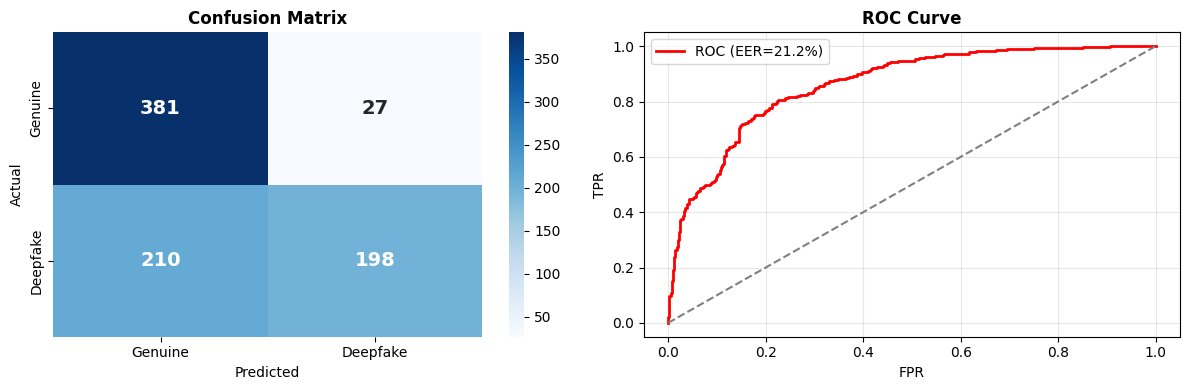

In [10]:
# STEP 10 — Evaluate on Test Set
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

model.load_state_dict(torch.load("./artifacts/deepfake_cnn.pt", map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for x, y in test_loader:
        out   = model(x.to(DEVICE))
        probs = torch.softmax(out, 1)[:,1]
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(y.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

acc  = accuracy_score(all_labels, all_preds)
f1   = f1_score(all_labels, all_preds)
cm   = confusion_matrix(all_labels, all_preds)
pca  = cm.diagonal() / cm.sum(1)
fpr, tpr, _ = roc_curve(all_labels, all_probs)
fnr  = 1 - tpr
eer  = (fpr[np.nanargmin(np.abs(fpr-fnr))] + fnr[np.nanargmin(np.abs(fpr-fnr))]) / 2

print("="*45)
print("        TEST SET RESULTS")
print("="*45)
print(f"Overall Accuracy : {acc*100:.2f}%  (target ≥ 80%)")
print(f"F1 Score         : {f1*100:.2f}%  (target ≥ 80%)")
print(f"Equal Error Rate : {eer*100:.2f}%  (target ≤ 12%)")
print(f"Genuine Acc      : {pca[0]*100:.2f}%  (target ≥ 75%)")
print(f"Deepfake Acc     : {pca[1]*100:.2f}%  (target ≥ 75%)")
print("="*45)
print(classification_report(all_labels, all_preds, target_names=["Genuine","Deepfake"]))

# Plot confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Genuine","Deepfake"],
            yticklabels=["Genuine","Deepfake"], ax=axes[0],
            annot_kws={"size":14,"weight":"bold"})
axes[0].set_title("Confusion Matrix", fontweight="bold")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

axes[1].plot(fpr, tpr, color="red", lw=2, label=f"ROC (EER={eer*100:.1f}%)")
axes[1].plot([0,1],[0,1],"--",color="gray")
axes[1].set_title("ROC Curve", fontweight="bold")
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [11]:
# STEP 11 — Save all artifacts
import json, pickle
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

config = {
    "SAMPLE_RATE": SAMPLE_RATE, "DURATION": DURATION,
    "N_MELS": N_MELS, "N_MFCC": N_MFCC,
    "N_FFT": N_FFT, "HOP_LENGTH": HOP_LENGTH,
    "LABEL_MAP": {"real":0,"fake":1},
    "INV_LABEL_MAP": {"0":"real","1":"fake"},
    "metrics": {
        "accuracy": float(acc), "f1": float(f1), "eer": float(eer),
        "per_class_accuracy": {"Genuine": float(pca[0]), "Deepfake": float(pca[1])},
        "confusion_matrix": cm.tolist()
    }
}
with open("./artifacts/config.json","w") as f: json.dump(config, f, indent=2)
with open("./artifacts/scaler.pkl","wb") as f: pickle.dump(scaler, f)

print("Saved: deepfake_cnn.pt, config.json, scaler.pkl")
print(f"\nFinal Metrics:")
print(f"  Accuracy : {acc*100:.2f}%")
print(f"  F1 Score : {f1*100:.2f}%")
print(f"  EER      : {eer*100:.2f}%")

Saved: deepfake_cnn.pt, config.json, scaler.pkl

Final Metrics:
  Accuracy : 70.96%
  F1 Score : 62.56%
  EER      : 21.20%


In [12]:
# STEP 12 — Download trained model files
from google.colab import files
files.download('./artifacts/deepfake_cnn.pt')
files.download('./artifacts/config.json')
files.download('./artifacts/scaler.pkl')
print("Downloaded! Upload these 3 files to GitHub to fix your Streamlit app.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded! Upload these 3 files to GitHub to fix your Streamlit app.


In [13]:
# STEP 13 — Test inference on sample files
def predict_audio(filepath):
    y   = load_audio(filepath)
    lm  = get_logmel(y)
    x   = torch.tensor(lm).unsqueeze(0).unsqueeze(0).to(DEVICE)
    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(x), dim=1)[0].cpu().numpy()
    pred = int(probs.argmax())
    label = "Genuine (Human)" if pred == 0 else "Deepfake (AI-Generated)"
    print(f"File      : {filepath}")
    print(f"Prediction: {label}")
    print(f"Confidence: {probs[pred]*100:.1f}%")
    print(f"P(Genuine): {probs[0]*100:.1f}% | P(Deepfake): {probs[1]*100:.1f}%")
    print()

# Test on real samples from test set
print("=== Testing on REAL audio ===")
real_files = test_df[test_df.label_name=='real']['filepath'].values[:3]
for f in real_files:
    predict_audio(f)

print("=== Testing on FAKE audio ===")
fake_files = test_df[test_df.label_name=='fake']['filepath'].values[:3]
for f in fake_files:
    predict_audio(f)

=== Testing on REAL audio ===
File      : ./for-rerec/for-rerecorded/testing/real/recording13722.wav_norm_mono.wav
Prediction: Genuine (Human)
Confidence: 100.0%
P(Genuine): 100.0% | P(Deepfake): 0.0%

File      : ./for-rerec/for-rerecorded/testing/real/recording14013.wav_norm_mono.wav
Prediction: Genuine (Human)
Confidence: 99.6%
P(Genuine): 99.6% | P(Deepfake): 0.4%

File      : ./for-rerec/for-rerecorded/testing/real/recording13760.wav_norm_mono.wav
Prediction: Genuine (Human)
Confidence: 95.0%
P(Genuine): 95.0% | P(Deepfake): 5.0%

=== Testing on FAKE audio ===
File      : ./for-rerec/for-rerecorded/testing/fake/recording13108.wav_norm_mono.wav
Prediction: Deepfake (AI-Generated)
Confidence: 77.0%
P(Genuine): 23.0% | P(Deepfake): 77.0%

File      : ./for-rerec/for-rerecorded/testing/fake/recording13369.wav_norm_mono.wav
Prediction: Deepfake (AI-Generated)
Confidence: 98.8%
P(Genuine): 1.2% | P(Deepfake): 98.8%

File      : ./for-rerec/for-rerecorded/testing/fake/recording13029.wav_